IMPORT

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data" / "processed" / "rfm_advanced_behavioural_features.csv"

TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup completed.")

Setup completed.


LOAD DATA

In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)

display(df.head())

(4338, 22)


,CustomerID,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Spend_Velocity,Purchase_Interval_Mean,Purchase_Interval_Std,Purchase_Interval_Max,...,Invoice_Value_Std,Invoice_Value_Max,Invoice_Value_Min,Invoice_Value_CV,Invoice_Value_Range,Spending_Momentum,Spending_Momentum_Ratio,Avg_Products_Per_Invoice,Std_Products_Per_Invoice,Avg_Quantity_Per_Invoice
0,12346,326,1,77183.60,1,1.000000,77183.600000,0.000000,0.000000,0.0,...,0.000000,77183.60,77183.60,0.000000,0.00,0.0000,0.000000,1.00,0.000000,74215.000000
1,12347,2,7,4310.00,366,0.019126,11.775956,60.333333,18.478817,90.0,...,341.070789,1294.32,224.82,0.553943,1069.50,13.8325,1.022758,26.00,11.430952,351.142857
2,12348,75,4,1797.24,283,0.014134,6.350671,94.000000,70.149840,173.0,...,301.159918,892.80,227.44,0.670272,665.36,-221.6200,0.604335,6.75,4.349329,585.250000
3,12349,19,1,1757.55,1,1.000000,1757.550000,0.000000,0.000000,0.0,...,0.000000,1757.55,1757.55,0.000000,0.00,0.0000,0.000000,73.00,0.000000,631.000000
4,12350,310,1,334.40,1,1.000000,334.400000,0.000000,0.000000,0.0,...,0.000000,334.40,334.40,0.000000,0.00,0.0000,0.000000,17.00,0.000000,197.000000


REMOVE CID

In [3]:
features = df.drop(columns=["CustomerID"])

print("Total Features:", features.shape[1])

print(features.columns.tolist())

Total Features: 21
['Recency', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Velocity', 'Spend_Velocity', 'Purchase_Interval_Mean', 'Purchase_Interval_Std', 'Purchase_Interval_Max', 'Purchase_Regularity_Index', 'Invoice_Value_Mean', 'Invoice_Value_Std', 'Invoice_Value_Max', 'Invoice_Value_Min', 'Invoice_Value_CV', 'Invoice_Value_Range', 'Spending_Momentum', 'Spending_Momentum_Ratio', 'Avg_Products_Per_Invoice', 'Std_Products_Per_Invoice', 'Avg_Quantity_Per_Invoice']


COREALTION HEATMAP

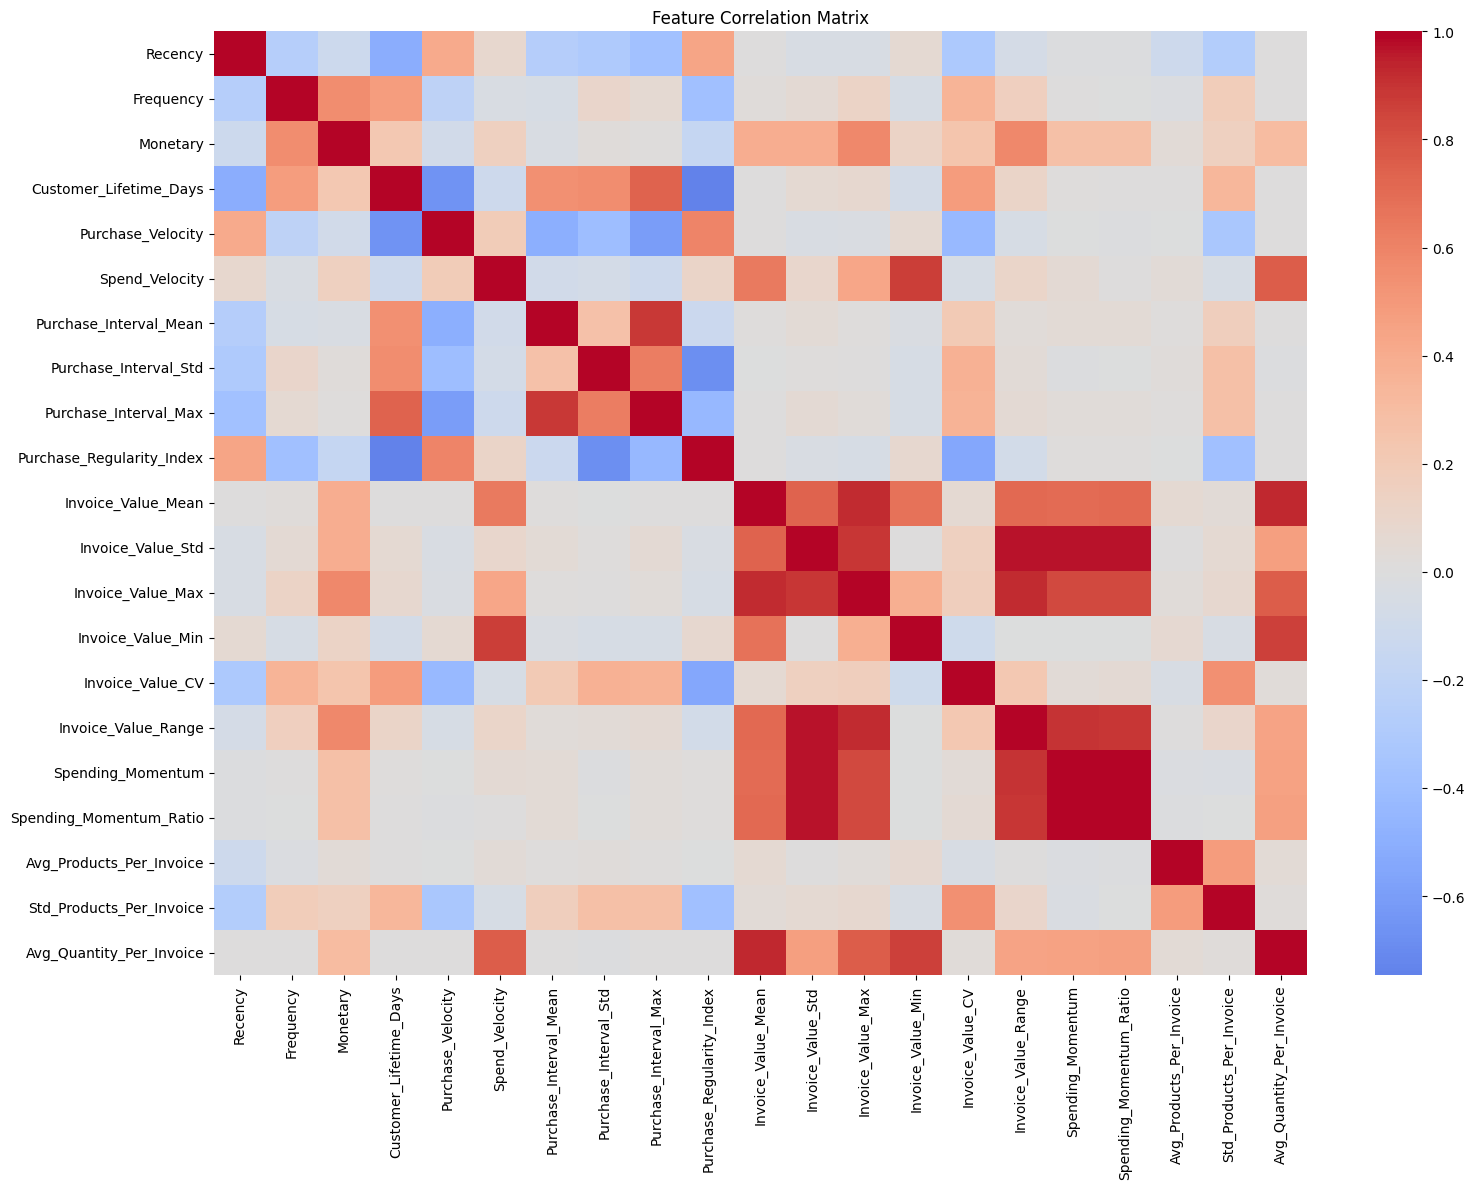

In [4]:
corr = features.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR/"feature_correlation_matrix.png",
    dpi=300
)

plt.show()

HIGHLY COREALTED FEATURES

In [5]:
corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

high_corr = []

for col in upper.columns:
    for row in upper.index:

        if upper.loc[row,col] > 0.90:

            high_corr.append({
                "Feature1":row,
                "Feature2":col,
                "Correlation":upper.loc[row,col]
            })

high_corr_df = pd.DataFrame(high_corr)

display(high_corr_df)

high_corr_df.to_csv(
    TABLES_DIR/"highly_correlated_features.csv",
    index=False
)

,Feature1,Feature2,Correlation
0,Invoice_Value_Mean,Invoice_Value_Max,0.921915
1,Invoice_Value_Std,Invoice_Value_Range,0.968642
2,Invoice_Value_Max,Invoice_Value_Range,0.919401
3,Invoice_Value_Std,Spending_Momentum,0.968482
4,Invoice_Value_Range,Spending_Momentum,0.902709
5,Invoice_Value_Std,Spending_Momentum_Ratio,0.967290
6,Spending_Momentum,Spending_Momentum_Ratio,0.986486
7,Invoice_Value_Mean,Avg_Quantity_Per_Invoice,0.930907


VARIANCE ANALYSIS

In [6]:
selector = VarianceThreshold()

selector.fit(features)

variance = pd.DataFrame({

    "Feature":features.columns,

    "Variance":selector.variances_

})

variance = variance.sort_values(
    by="Variance",
    ascending=False
)

display(variance)

variance.to_csv(
    TABLES_DIR/"feature_variance.csv",
    index=False
)

,Feature,Variance
2,Monetary,280202.270000
16,Spending_Momentum,177284.960000
15,Invoice_Value_Range,168466.700000
12,Invoice_Value_Max,168465.850000
11,Invoice_Value_Std,119123.945974
10,Invoice_Value_Mean,84232.800000
5,Spend_Velocity,77183.488875
13,Invoice_Value_Min,77183.220000
20,Avg_Quantity_Per_Invoice,74214.000000
17,Spending_Momentum_Ratio,58092.965517


PCA EXPLAINED VARIANCE

In [18]:
scaled = RobustScaler().fit_transform(features)

pca = PCA()

pca.fit(scaled)

explained = pd.DataFrame({

    "PC":range(1,len(pca.explained_variance_ratio_)+1),

    "Explained Variance":pca.explained_variance_ratio_

})

display(explained.head(15))

,PC,Explained Variance
0,1,9.995472e-01
1,2,2.635090e-04
2,3,8.562602e-05
3,4,6.446438e-05
4,5,1.619817e-05
5,6,8.247527e-06
6,7,4.448971e-06
7,8,2.474912e-06
8,9,2.266971e-06
9,10,1.404887e-06


TEST REFINED

In [14]:
# ==========================================================
# TEST REFINED ADVANCED FEATURE SET
# ==========================================================

refined_features = df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Customer_Lifetime_Days",
        "Purchase_Velocity",
        "Purchase_Interval_Std",
        "Purchase_Regularity_Index",
        "Invoice_Value_CV"
    ]
]

print("Refined feature set shape:", refined_features.shape)
print(refined_features.columns.tolist())

Refined feature set shape: (4338, 8)
['Recency', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Velocity', 'Purchase_Interval_Std', 'Purchase_Regularity_Index', 'Invoice_Value_CV']


LOG TRANSFORMATION

In [15]:
# ==========================================================
# LOG TRANSFORMATION
# ==========================================================

import numpy as np

refined_log = refined_features.copy()

log_features = [
    "Frequency",
    "Monetary",
    "Customer_Lifetime_Days",
    "Purchase_Velocity",
    "Purchase_Interval_Std"
]

for col in log_features:
    refined_log[col] = np.log1p(refined_log[col])

print("Log transformation completed.")
display(refined_log.head())

Log transformation completed.


,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV
0,326,0.693147,11.253955,0.693147,0.693147,0.000000,1.000000,0.000000
1,2,2.079442,8.368925,5.905362,0.018945,2.969328,0.051338,0.553943
2,75,1.609438,7.494564,5.648974,0.014035,4.264788,0.014055,0.670272
3,19,0.693147,7.472245,0.693147,0.693147,0.000000,1.000000,0.000000
4,310,0.693147,5.815324,0.693147,0.693147,0.000000,1.000000,0.000000


DISTRIBUTION AGAIN

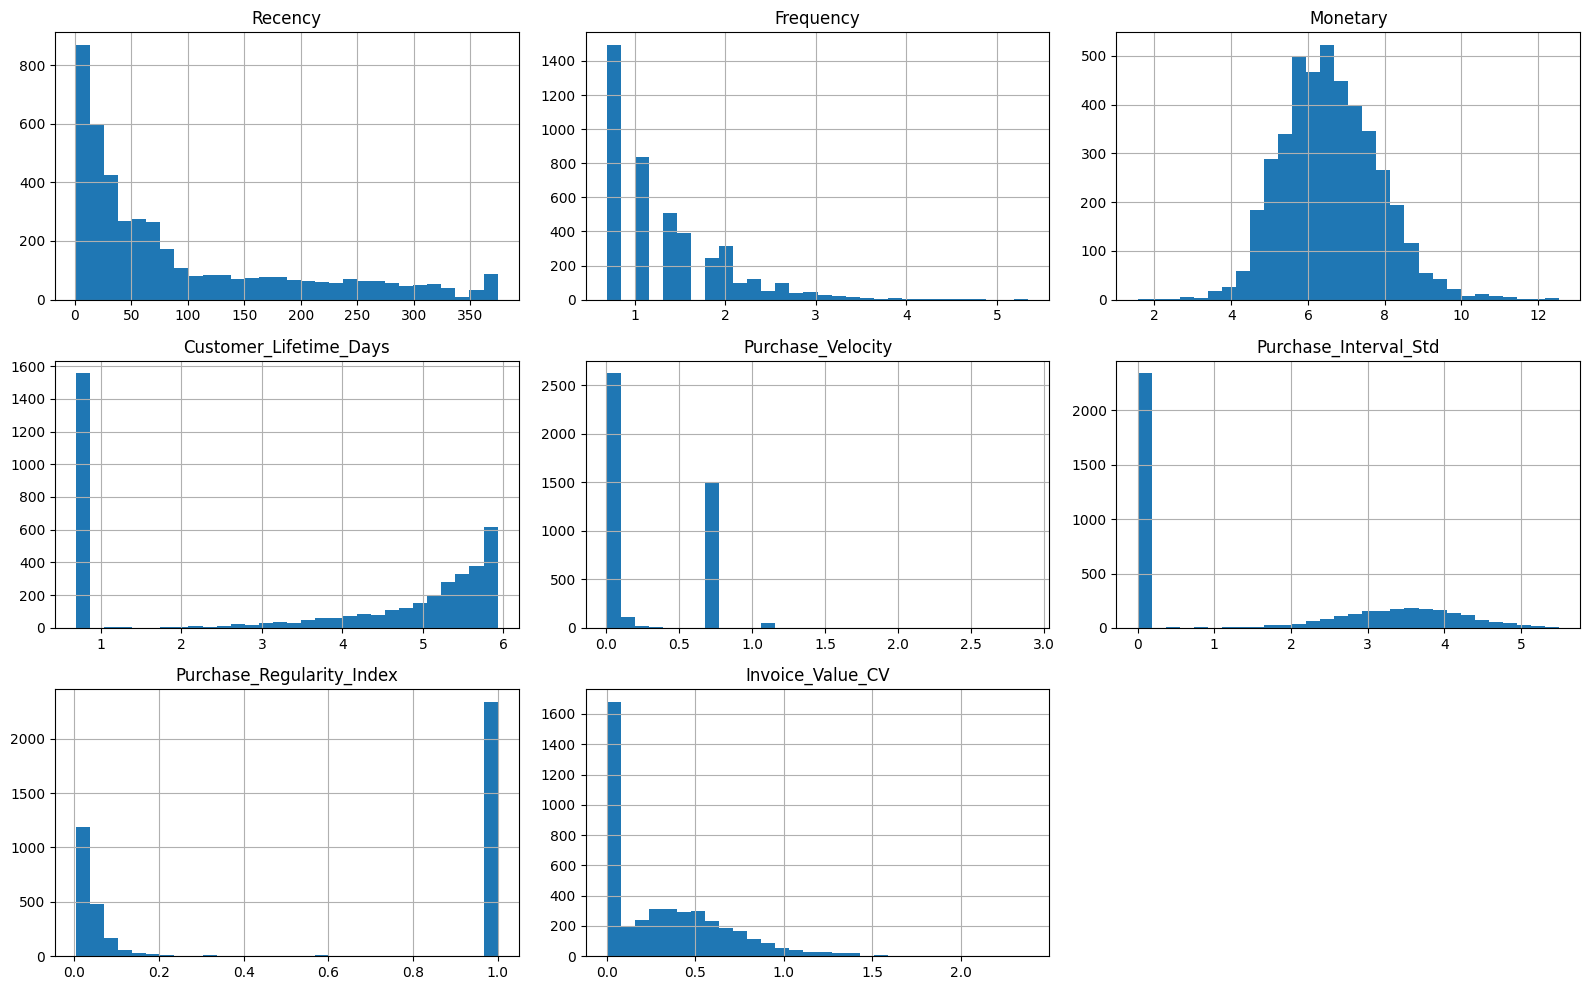

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.000000,18.000000,51.000000,142.000000,374.000000
Frequency,4338.0,1.345582,0.683104,0.693147,0.693147,1.098612,1.791759,5.347108
Monetary,4338.0,6.588562,1.258438,1.558145,5.728418,6.506636,7.415535,12.543284
Customer_Lifetime_Days,4338.0,3.498618,2.210910,0.693147,0.693147,4.548586,5.536348,5.926926
Purchase_Velocity,4338.0,0.280878,0.332980,0.005450,0.020032,0.045059,0.693147,2.890372
Purchase_Interval_Std,4338.0,1.584142,1.804632,0.000000,0.000000,0.000000,3.379735,5.495271
Purchase_Regularity_Index,4338.0,0.561104,0.476546,0.004106,0.034056,1.000000,1.000000,1.000000
Invoice_Value_CV,4338.0,0.318584,0.340910,0.000000,0.000000,0.253367,0.536834,2.380349


In [16]:
import matplotlib.pyplot as plt

refined_log.hist(figsize=(16,10), bins=30)

plt.tight_layout()
plt.show()

display(refined_log.describe().T)

PCS ON REFINED FEATURES

In [19]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# Scale refined features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(refined_log)

# PCA
pca = PCA()
pca.fit(X_scaled)

pca_results = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance": pca.explained_variance_ratio_
})

display(pca_results)

print("Total variance (first 3 PCs):",
      round(pca.explained_variance_ratio_[:3].sum(), 4))

,PC,Explained Variance
0,1,0.636096
1,2,0.143942
2,3,0.077555
3,4,0.070348
4,5,0.043341
5,6,0.024381
6,7,0.002939
7,8,0.001398


Total variance (first 3 PCs): 0.8576


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

K_VALUE = 4

kmeans = KMeans(
    n_clusters=K_VALUE,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

print("="*70)
print("REFINED FEATURE SET RESULTS")
print("="*70)

print("Silhouette Score      :", round(silhouette_score(X_scaled, labels),4))
print("Davies-Bouldin Index :", round(davies_bouldin_score(X_scaled, labels),4))
print("Calinski-Harabasz    :", round(calinski_harabasz_score(X_scaled, labels),2))

cluster_sizes = pd.Series(labels).value_counts().sort_index()

print("\nCluster Sizes")
print(cluster_sizes)

REFINED FEATURE SET RESULTS
Silhouette Score      : 0.4096
Davies-Bouldin Index : 0.9517
Calinski-Harabasz    : 3253.36

Cluster Sizes
0     872
1    1938
2     741
3     787
Name: count, dtype: int64


PCA PLOT

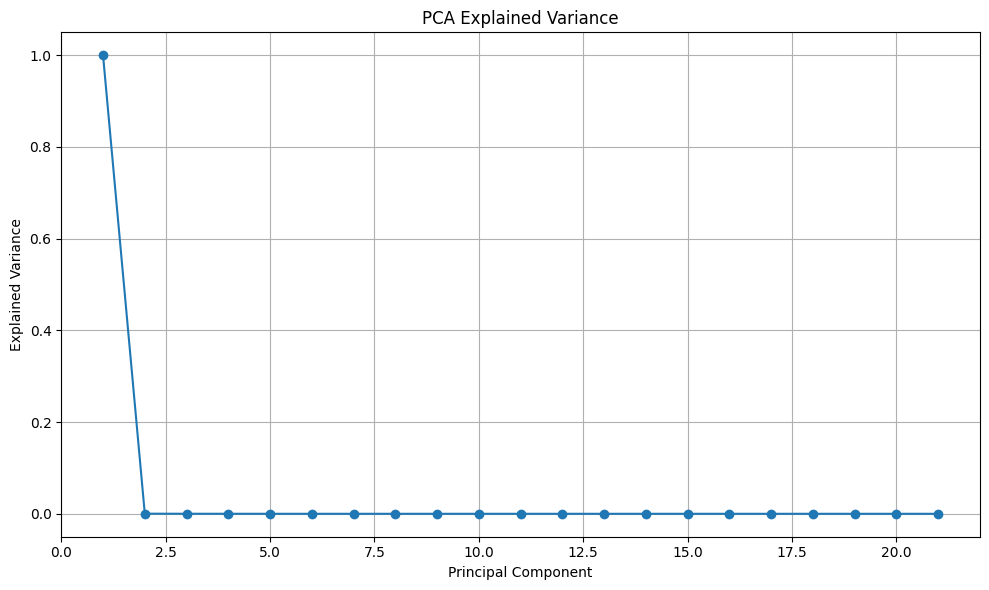

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    explained["PC"],
    explained["Explained Variance"],
    marker="o"
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR/"pca_explained_variance.png",
    dpi=300
)

plt.show()

FEATURES SUMMARY

In [9]:
summary = pd.DataFrame({

    "Feature":features.columns,

    "Missing":features.isna().sum(),

    "Unique":features.nunique(),

    "Variance":selector.variances_

})

summary = summary.sort_values(
    by="Variance",
    ascending=False
)

display(summary)

summary.to_csv(
    TABLES_DIR/"feature_summary.csv",
    index=False
)

,Feature,Missing,Unique,Variance
Monetary,Monetary,0,4246,280202.270000
Spending_Momentum,Spending_Momentum,0,2825,177284.960000
Invoice_Value_Range,Invoice_Value_Range,0,2801,168466.700000
Invoice_Value_Max,Invoice_Value_Max,0,4176,168465.850000
Invoice_Value_Std,Invoice_Value_Std,0,2834,119123.945974
Invoice_Value_Mean,Invoice_Value_Mean,0,4259,84232.800000
Spend_Velocity,Spend_Velocity,0,4284,77183.488875
Invoice_Value_Min,Invoice_Value_Min,0,3676,77183.220000
Avg_Quantity_Per_Invoice,Avg_Quantity_Per_Invoice,0,2130,74214.000000
Spending_Momentum_Ratio,Spending_Momentum_Ratio,0,2834,58092.965517


In [10]:
print("="*80)

print("FEATURE SELECTION COMPLETED")

print("="*80)

print("Review the following before selecting the final feature set:")

print()

print("1. Highly correlated features")

print("2. Low variance features")

print("3. PCA Explained Variance")

print("4. Feature distributions")

print()

print("Next step:")

print("Use these outputs to decide the final behavioural feature set.")

print("="*80)

FEATURE SELECTION COMPLETED
Review the following before selecting the final feature set:

1. Highly correlated features
2. Low variance features
3. PCA Explained Variance
4. Feature distributions

Next step:
Use these outputs to decide the final behavioural feature set.
